# Machine Learning Play

While `predicting_success.ipynb` functions as a demo on how machine learning techniques can be applied using a demo (older) version of the database, in this notebook we experiment with different models using the most up to date version of the database.

# Loading Libraries

We import a suite of modules as in `predicting_succes.ipynb`.

In [1]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use functions we have previously created.
import sj_db_functions as dbfunc

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle

# We set the seed for replicability.
np.random.seed(2)


In [2]:
basis_size=10
success_criteria=50
(basis_size,success_criteria)

(10, 50)

# Obtaining Data

We will use data taken from our SQLite database. We can load modeling data easily using `dbfunc`.

In [3]:
# We connect to the most recent copy of the database.
connection=sqlite3.connect('shonen_jump.sqlite3')
cursor=connection.cursor()
# Displaying the earliest and latest recorded dates in the database.
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2026-03-29.


In [4]:
df=dbfunc.load_modeling_data(connection,basis_size)
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,place_chap_4,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,release_year,release_month
0,Akane-banashi,Other,0,8.3,1,1,2,1,6,11,7,11,8,12,9,8,10,2022,2
1,Aliens Area,Battle,1,9.9,2,1,3,1,6,8,7,8,10,10,13,17,19,2022,6
2,Astro Royale,Battle,1,7.1,2,1,3,1,4,11,5,9,10,6,6,8,11,2024,4
3,Cipher Academy,Other,0,9.7,1,1,4,1,5,11,8,12,8,14,12,13,13,2022,11
4,Dear Anemone,Battle,1,10.8,1,1,2,1,6,10,8,10,9,12,17,17,18,2024,2
5,Do Retry,Sports,1,11.4,1,1,4,1,4,8,5,12,11,17,17,19,20,2023,5
6,Earthchild,Other,1,8.9,1,1,2,1,6,11,8,12,8,13,12,7,11,2022,2
7,Ekiden Bros,Sports,1,11.2,1,1,4,1,7,10,9,12,16,8,10,20,19,2025,6
8,Embers,Sports,0,11.2,1,1,2,1,6,10,12,7,12,11,16,17,20,2025,2
9,Fabricant 100,Battle,1,10.3,1,1,4,1,6,10,12,9,14,11,11,15,14,2022,12


In [5]:
success_column=dbfunc.success_or_failure(connection,success_criteria=success_criteria,titles=df['title'].to_list())
df=df.merge(success_column,left_on='title',right_on='title')
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,place_chap_4,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,release_year,release_month,success
0,Akane-banashi,Other,0,8.3,1,1,2,1,6,11,7,11,8,12,9,8,10,2022,2,1.0
1,Aliens Area,Battle,1,9.9,2,1,3,1,6,8,7,8,10,10,13,17,19,2022,6,0.0
2,Astro Royale,Battle,1,7.1,2,1,3,1,4,11,5,9,10,6,6,8,11,2024,4,1.0
3,Cipher Academy,Other,0,9.7,1,1,4,1,5,11,8,12,8,14,12,13,13,2022,11,1.0
4,Dear Anemone,Battle,1,10.8,1,1,2,1,6,10,8,10,9,12,17,17,18,2024,2,0.0
5,Do Retry,Sports,1,11.4,1,1,4,1,4,8,5,12,11,17,17,19,20,2023,5,0.0
6,Earthchild,Other,1,8.9,1,1,2,1,6,11,8,12,8,13,12,7,11,2022,2,0.0
7,Ekiden Bros,Sports,1,11.2,1,1,4,1,7,10,9,12,16,8,10,20,19,2025,6,0.0
8,Embers,Sports,0,11.2,1,1,2,1,6,10,12,7,12,11,16,17,20,2025,2,0.0
9,Fabricant 100,Battle,1,10.3,1,1,4,1,6,10,12,9,14,11,11,15,14,2022,12,0.0


We also want stats on just the chapters 8, 9, and 10.  First we get the number of color pages over those chapters.

In [6]:
mini_color_df=pd.read_sql_query("""
SELECT series AS title, COUNT(series) AS limited_color FROM chapters WHERE type='Color' AND chapter BETWEEN 8 AND :basis_size GROUP BY series;
""",con=connection, params={'basis_size':basis_size})

In [7]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

In [8]:
# Merging the new column.
df=df.merge(mini_color_df, how='left',left_on='title',right_on='title')

In [9]:
df['limited_color'] = df['limited_color'].fillna(0).astype(int)
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,release_year,release_month,success,limited_color
0,Akane-banashi,Other,0,8.3,1,1,2,1,6,11,...,11,8,12,9,8,10,2022,2,1.0,0
1,Aliens Area,Battle,1,9.9,2,1,3,1,6,8,...,8,10,10,13,17,19,2022,6,0.0,0
2,Astro Royale,Battle,1,7.1,2,1,3,1,4,11,...,9,10,6,6,8,11,2024,4,1.0,1
3,Cipher Academy,Other,0,9.7,1,1,4,1,5,11,...,12,8,14,12,13,13,2022,11,1.0,0
4,Dear Anemone,Battle,1,10.8,1,1,2,1,6,10,...,10,9,12,17,17,18,2024,2,0.0,0
5,Do Retry,Sports,1,11.4,1,1,4,1,4,8,...,12,11,17,17,19,20,2023,5,0.0,0
6,Earthchild,Other,1,8.9,1,1,2,1,6,11,...,12,8,13,12,7,11,2022,2,0.0,0
7,Ekiden Bros,Sports,1,11.2,1,1,4,1,7,10,...,12,16,8,10,20,19,2025,6,0.0,0
8,Embers,Sports,0,11.2,1,1,2,1,6,10,...,7,12,11,16,17,20,2025,2,0.0,0
9,Fabricant 100,Battle,1,10.3,1,1,4,1,6,10,...,9,14,11,11,15,14,2022,12,0.0,0


In [10]:
# We make a list of column titles ranking the placements of the first 7 chapters.
early_placements=[f'place_chap_{i}' for i in range(1,8)]
early_placements

['place_chap_1',
 'place_chap_2',
 'place_chap_3',
 'place_chap_4',
 'place_chap_5',
 'place_chap_6',
 'place_chap_7']

In [11]:
# We also make a list of column titles ranking the placements of the chapters after chapter 7.
limited_placements=[f'place_chap_{i}' for i in range(8,basis_size+1)]
limited_placements

['place_chap_8', 'place_chap_9', 'place_chap_10']

In [12]:
# We add a column by computing the average placement of chapters after chapter 7 for each series.
df['limited_avg_placement']=df[limited_placements].mean(axis=1)
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,release_year,release_month,success,limited_color,limited_avg_placement
0,Akane-banashi,Other,0,8.3,1,1,2,1,6,11,...,8,12,9,8,10,2022,2,1.0,0,9.000000
1,Aliens Area,Battle,1,9.9,2,1,3,1,6,8,...,10,10,13,17,19,2022,6,0.0,0,16.333333
2,Astro Royale,Battle,1,7.1,2,1,3,1,4,11,...,10,6,6,8,11,2024,4,1.0,1,8.333333
3,Cipher Academy,Other,0,9.7,1,1,4,1,5,11,...,8,14,12,13,13,2022,11,1.0,0,12.666667
4,Dear Anemone,Battle,1,10.8,1,1,2,1,6,10,...,9,12,17,17,18,2024,2,0.0,0,17.333333
5,Do Retry,Sports,1,11.4,1,1,4,1,4,8,...,11,17,17,19,20,2023,5,0.0,0,18.666667
6,Earthchild,Other,1,8.9,1,1,2,1,6,11,...,8,13,12,7,11,2022,2,0.0,0,10.000000
7,Ekiden Bros,Sports,1,11.2,1,1,4,1,7,10,...,16,8,10,20,19,2025,6,0.0,0,16.333333
8,Embers,Sports,0,11.2,1,1,2,1,6,10,...,12,11,16,17,20,2025,2,0.0,0,17.666667
9,Fabricant 100,Battle,1,10.3,1,1,4,1,6,10,...,14,11,11,15,14,2022,12,0.0,0,13.333333


In [13]:
# Jujutsu Kaisen Modulo is a special case that was always intended to run for a limited time.
# We shall just drop this row.
df=df[df['title']!='Jujutsu Kaisen Modulo']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 47
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  47 non-null     object 
 1   genre                  47 non-null     object 
 2   one_creator            47 non-null     int64  
 3   average_placement      47 non-null     float64
 4   color_pages            47 non-null     int64  
 5   cover_pages            47 non-null     int64  
 6   batch_size             47 non-null     int64  
 7   place_chap_1           47 non-null     int32  
 8   place_chap_2           47 non-null     int32  
 9   place_chap_3           47 non-null     int32  
 10  place_chap_4           47 non-null     int32  
 11  place_chap_5           47 non-null     int32  
 12  place_chap_6           47 non-null     int32  
 13  place_chap_7           47 non-null     int32  
 14  place_chap_8           47 non-null     int32  
 15  place_chap_9 

# Train/Test Split

In [15]:
train_df, test_df = train_test_split(df.dropna(),train_size=.8, random_state=9, stratify=df.dropna()['success'])
train_df.info()
test_df.info()

X_train=train_df.drop(['success'],axis=1)
X_test=test_df.drop(['success'],axis=1)
y_train=train_df['success'].astype(int)
y_test=test_df['success'].astype(int)

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 9 to 22
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  33 non-null     object 
 1   genre                  33 non-null     object 
 2   one_creator            33 non-null     int64  
 3   average_placement      33 non-null     float64
 4   color_pages            33 non-null     int64  
 5   cover_pages            33 non-null     int64  
 6   batch_size             33 non-null     int64  
 7   place_chap_1           33 non-null     int32  
 8   place_chap_2           33 non-null     int32  
 9   place_chap_3           33 non-null     int32  
 10  place_chap_4           33 non-null     int32  
 11  place_chap_5           33 non-null     int32  
 12  place_chap_6           33 non-null     int32  
 13  place_chap_7           33 non-null     int32  
 14  place_chap_8           33 non-null     int32  
 15  place_chap_9 

<Axes: xlabel='limited_color', ylabel='count'>

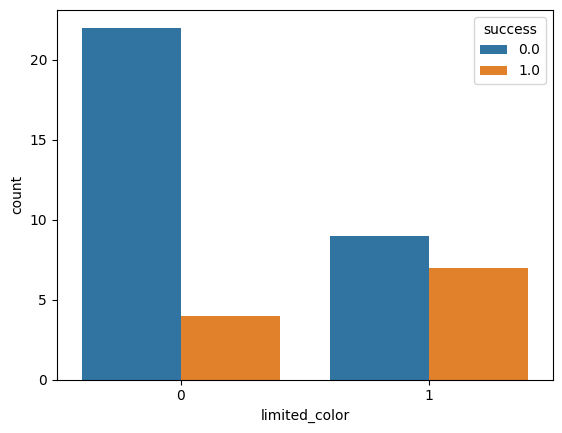

In [16]:
sns.countplot(data=df.dropna(), x='limited_color', hue='success')

<Axes: xlabel='color_pages', ylabel='count'>

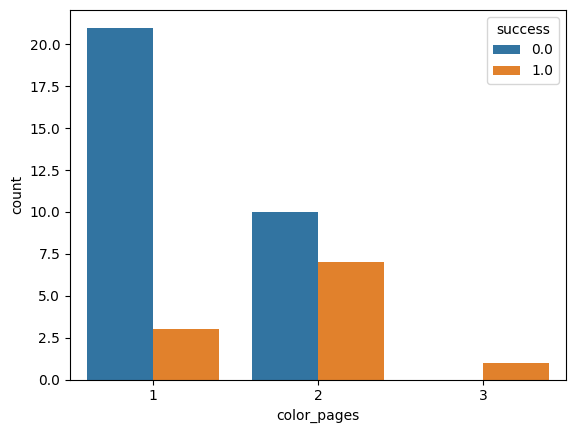

In [17]:
sns.countplot(data=df.dropna(), x='color_pages', hue='success')

# Model Creation

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 47
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  47 non-null     object 
 1   genre                  47 non-null     object 
 2   one_creator            47 non-null     int64  
 3   average_placement      47 non-null     float64
 4   color_pages            47 non-null     int64  
 5   cover_pages            47 non-null     int64  
 6   batch_size             47 non-null     int64  
 7   place_chap_1           47 non-null     int32  
 8   place_chap_2           47 non-null     int32  
 9   place_chap_3           47 non-null     int32  
 10  place_chap_4           47 non-null     int32  
 11  place_chap_5           47 non-null     int32  
 12  place_chap_6           47 non-null     int32  
 13  place_chap_7           47 non-null     int32  
 14  place_chap_8           47 non-null     int32  
 15  place_chap_9 

In [19]:
transformers=[('OneHotEncoding', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),['genre', 'release_month']),
              ('Scaler',StandardScaler(),['average_placement','color_pages','batch_size',
                                          'limited_color', 'limited_avg_placement']+limited_placements+early_placements),
              ('Column Dropper', 'drop', ['title','cover_pages', 'release_year'])]

# We define the preprocesser using the transformers defined above. 
preprocessor=ColumnTransformer(transformers=transformers, remainder='passthrough', force_int_remainder_cols=False, verbose_feature_names_out=False)
# We will include another step which uses the column names so we set the preprocessor to retain the column names (i.e. to output a dataframe)
preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('OneHotEncoding',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['genre', 'release_month']),
                                ('Scaler', StandardScaler(),
                                 ['average_placement', 'color_pages',
                                  'batch_size', 'limited_color',
                                  'limited_avg_placement', 'place_chap_8',
                                  'place_chap_9', 'place_chap_10',
                                  'place_chap_1', 'place_chap_2',
                                  'place_chap_3', 'place_chap_4',
                                  'place_chap_5', 'place_chap_6',
                                  'place_chap_7']),
                                ('Column Dropper', 'drop',
                                 ['title', 'cover_pages', 'release_year'])],
                  verbose_feature_names_out=False)

## Pipeline Definition

In [20]:
pipe=Pipeline(steps=[('Preprocess', preprocessor),('FeatureSelection','passthrough'),('Classifier',DecisionTreeClassifier())])

## Feature selectors

We will create two pipelines which let us perform RFECV on the data-- one where we use all the data and one where we only use chapters beyond chapter 8.

In [21]:
# We will use the following RFECV object in each pipeline.
feature_selector=RFECV(RandomForestClassifier(random_state=11),cv=3,scoring='roc_auc')

In [22]:
# We make two separate preprocessors, one focusing on all the chapters and one on those beyond 8.
all_preprocessor=ColumnTransformer(transformers=[
    ('DropLimited','drop',['limited_color','limited_avg_placement'])
], remainder='passthrough', force_int_remainder_cols=False, verbose_feature_names_out=False)

all_preprocessor.set_output(transform='pandas')

limited_preprocessor=ColumnTransformer(transformers=[
    ('DropEarly','drop',early_placements+['color_pages','average_placement'])
], remainder='passthrough', force_int_remainder_cols=False, verbose_feature_names_out=False)

limited_preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('DropEarly', 'drop',
                                 ['place_chap_1', 'place_chap_2',
                                  'place_chap_3', 'place_chap_4',
                                  'place_chap_5', 'place_chap_6',
                                  'place_chap_7', 'color_pages',
                                  'average_placement'])],
                  verbose_feature_names_out=False)

In [23]:
# Now we make a pipeline for each.
all_rfecv=Pipeline(steps=[('Prep', all_preprocessor),('RFECV',feature_selector)])
limited_rfecv=Pipeline(steps=[('Prep', limited_preprocessor),('RFECV',feature_selector)])

## Grid search parameters

In [24]:

feature_dict={'FeatureSelection':[
    all_rfecv,
    limited_rfecv,
    ColumnTransformer(transformers=[('All','drop',['limited_color','limited_avg_placement'])],
                      remainder='passthrough',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('Limited','drop',early_placements+['color_pages','average_placement'])],
                      remainder='passthrough',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('OnlyAllAvgPlacement','passthrough',['average_placement'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('OnlyLimitedAvgPlacement','passthrough',['limited_avg_placement'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('DropMostAll','passthrough',['average_placement', 'color_pages'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False),                     
    ColumnTransformer(transformers=[('DropMostLimited','passthrough',['limited_avg_placement', 'limited_color'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False), 
    ColumnTransformer(transformers=[('DropSomeLimited','passthrough',limited_placements+['limited_color'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False)     
]}


# Each dictionary should include a classifier and the parameters we wish to iterate through.
parameters=[
    {'Classifier':[LogisticRegression(class_weight=None, solver='liblinear')],
     'Classifier__max_iter':[500],
     'Classifier__solver':['lbfgs', 'liblinear'],
     'Classifier__class_weight':[None,'balanced']},
    {'Classifier':[SVC(kernel='linear')],
     'Classifier__C':[.001,.01,.1,1]},
    {'Classifier':[LinearDiscriminantAnalysis()],
     'Classifier__solver':['svd','lsqr']}

]

In [25]:
parameters=[param|feature_dict for param in parameters]
parameters

[{'Classifier': [LogisticRegression(solver='liblinear')],
  'Classifier__max_iter': [500],
  'Classifier__solver': ['lbfgs', 'liblinear'],
  'Classifier__class_weight': [None, 'balanced'],
  'FeatureSelection': [Pipeline(steps=[('Prep',
                    ColumnTransformer(force_int_remainder_cols=False,
                                      remainder='passthrough',
                                      transformers=[('DropLimited', 'drop',
                                                     ['limited_color',
                                                      'limited_avg_placement'])],
                                      verbose_feature_names_out=False)),
                   ('RFECV',
                    RFECV(cv=3, estimator=RandomForestClassifier(random_state=11),
                          scoring='roc_auc'))]),
   Pipeline(steps=[('Prep',
                    ColumnTransformer(force_int_remainder_cols=False,
                                      remainder='passthrough',
      

In [26]:
grid_search=GridSearchCV(pipe,param_grid=parameters,cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

In [27]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('Preprocess',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('OneHotEncoding',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['genre',
                                                                          'release_month']),
                                                                        ('Scaler',
                                                                         StandardScaler(),
                                                                         ['average_placement',
                                                                          'color_pages',
                                                                          'batch_size',
                                                                          'limit...
                                               ColumnTransformer(force_int_remainder_cols=False,
                                                                 transformers=[('DropMostLimited',
                                                                                'passthrough',
                                                                                ['limited_avg_placement',
                                                                                 'limited_color'])],
                                                                 verbose_feature_names_out=False),
                                               ColumnTransformer(force_int_remainder_cols=False,
                                                                 transformers=[('DropSomeLimited',
                                                                                'passthrough',
                                                                                ['place_chap_8',
                                                                                 'place_chap_9',
                                                                                 'place_chap_10',
                                                                                 'limited_color'])],
                                                                 verbose_feature_names_out=False)]}],
             scoring='roc_auc')

In [28]:
print(f"A good score on the training set should be at least {1-(y_train.sum()/len(y_train))}.")

print(f"A good score on the testing set should be at least {1-(y_test.sum()/len(y_test))}.")

A good score on the training set should be at least 0.7272727272727273.
A good score on the testing set should be at least 0.7777777777777778.


In [29]:
grid_search.best_score_

0.95

In [30]:
grid_search.best_estimator_

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages', 'batch_size',
                                                   'limited_color',
                                                   'limited_avg_placement',
                                                   'place_chap_8'...
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('Limited', 'drop',
                                                  ['place_chap_1',
                                                   'place_chap_2',
                                                   'place_chap_3',
                                                   'place_chap_4',
                                                   'place_chap_5',
                                                   'place_chap_6',
                                                   'place_chap_7',
                                                   'color_pages',
                                                   'average_placement'])],
                                   verbose_feature_names_out=False)),
                ('Classifier',
                 LogisticRegression(max_iter=500, solver='liblinear'))])

In [31]:
best_model=grid_search.best_estimator_
best_model.score(X_test,y_test)

0.7777777777777778

In [32]:
pd.concat([test_df[['title','success']].reset_index(drop=True),pd.Series(best_model.predict(X_test), name='predict')], axis=1)

,title,success,predict
0,Shadow Eliminators,0.0,0
1,Yokai Buster Murakami,0.0,0
2,Tokyo Demon Bride Story,0.0,0
3,The Ichinose Family's Deadly Sins,0.0,1
4,Super Psychic Policeman Chojo,1.0,1
5,Psych House,0.0,0
6,Dear Anemone,0.0,0
7,Super Smartphone,0.0,1
8,Akane-banashi,1.0,1


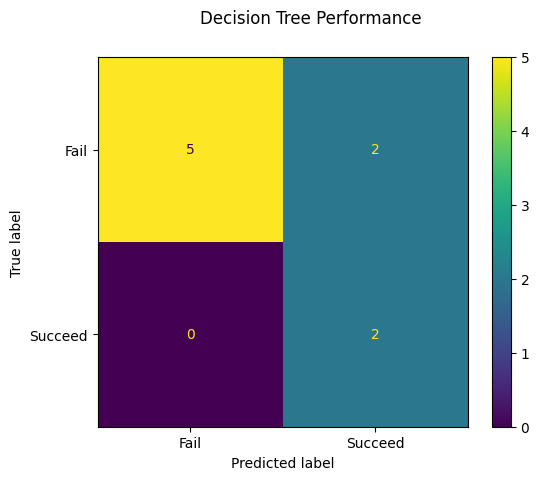

In [33]:
# Defining the matrix.
c_matrix = metrics.confusion_matrix(y_test, best_model.predict(X_test), labels=[0,1])

# Setting the display options.
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = c_matrix, display_labels = ['Fail', 'Succeed'])
cm_display.plot()
# Adding a title.
plt.gcf().suptitle('Decision Tree Performance')
# Removing grid lines for clarity.
plt.grid(False)
plt.show()

In [34]:
pd.concat([df['title'].reset_index(drop=True),pd.Series(best_model.predict(df.drop(columns=['success'])), name='predict')], axis=1)

,title,predict
0,Akane-banashi,1
1,Aliens Area,0
2,Astro Royale,1
3,Cipher Academy,1
4,Dear Anemone,0
5,Do Retry,0
6,Earthchild,0
7,Ekiden Bros,0
8,Embers,0
9,Fabricant 100,0
